In [29]:
from typing import Dict, List
import h5py
from math import sqrt
import numpy as np
import scipy as sp
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt
import cirq
import openfermion as of
import qiskit
from quimb.tensor import DMRG
from quimb_tebd import (
    pauli_sum_to_mpo, get_drmg_ground_state, trotter_circuit_from_psum,
    energy_vs_d, total_number_qubit_operator, get_evolved_states,
    fill_subspace_matrices_mps, mps_to_vector, exact_evolved_states,
    fill_subspace_matrices_vectors
)

In [20]:
def tfim_hamiltonian(l: int, j: float, g: float) -> cirq.PauliSum:
    """Hamiltonian for the transverse-field Ising model.
    H = -J (sum_ij Z_i Z_j + g sum_j X_j)
    Here we are using a 1D graph with non-periodic boundary conditions."""

    qs = cirq.LineQubit.range(l)
    h = cirq.PauliSum()
    for i in range(l):
        h += -j * g * cirq.X.on(qs[i])
        if i != l - 1:
            h += -j * cirq.Z.on(qs[i]) * cirq.Z.on(qs[i+1])
    return h

In [21]:
l = 6
j = 1.0
g = 2.0
mpo_bond = 100
bond_dims = [2, 4, 6, 8]
d = 20
tau = 0.1
steps = 10
eps = 1e-10

hamiltonian = tfim_hamiltonian(l, j, g)
ham_mpo = pauli_sum_to_mpo(hamiltonian, hamiltonian.qubits, mpo_bond)

# Get energy by exact diagonalization

In [33]:
ham_matrix = hamiltonian.matrix()
eigvals, eigvecs = sp.linalg.eigh(ham_matrix)
energy_exact = np.min(eigvals)
print(f"Exact energy = {energy_exact}")

Exact energy = -12.63096427649294


## Do DMRG at various bond dimensions

In [22]:
dmrg_ground_states = []
dmrg_energies = []
for chi_dmrg in bond_dims:
    print(f"chi = {chi_dmrg}")
    dmrg = DMRG(ham_mpo, chi_dmrg)
    converged = dmrg.solve()
    if not converged:
        print("DMRG did not converge!")
    ground_energy = dmrg.energy.real
    print(f"Got energy {ground_energy}")
    ground_state = dmrg.state
    dmrg_ground_states.append(ground_state.copy())
    dmrg_energies.append(ground_energy)

chi = 2
Got energy -12.630872627668092
chi = 4
Got energy -12.630964273980725
chi = 6
Got energy -12.630964273981341
chi = 8
Got energy -12.630964273980982


# Do Krylov at various bond dimensions.

Each starts with the DMRG ground state that has the smallest bond dimension.

In [23]:
# Compile the circuit.
ev_circuit = trotter_circuit_from_psum(hamiltonian, tau, steps)
ev_circuit_transpiled = qiskit.transpile(ev_circuit)

In [24]:
krylov_energies = np.zeros((len(bond_dims), d-1), dtype=float)
ref_state = dmrg_ground_states[0].copy()
for i, chi in enumerate(bond_dims):
    states = get_evolved_states(ev_circuit_transpiled, ref_state, d, chi, None)
    h, s = fill_subspace_matrices_mps(states, ham_mpo)
    energies, num_kept = energy_vs_d(h, s, method="threshold", eps=eps)
    krylov_energies[i, :] = energies

In [34]:
krylov_errs = np.abs(krylov_energies - energy_exact)

/var/folders/62/vpq4vzfx3zlfyyr3mw8zdmrc0000gn/T/ipykernel_1741/3990548503.py:7: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "." (-> marker='.'). The keyword argument will take precedence.
  ax[0].plot(krylov_energies[i, :], '.', marker=markers[i], label=f"TEBD chi={chi}")
/var/folders/62/vpq4vzfx3zlfyyr3mw8zdmrc0000gn/T/ipykernel_1741/3990548503.py:8: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "." (-> marker='.'). The keyword argument will take precedence.
  ax[1].plot(krylov_errs[i, :], '.', marker=markers[i], label=f"TEBD chi={chi}")


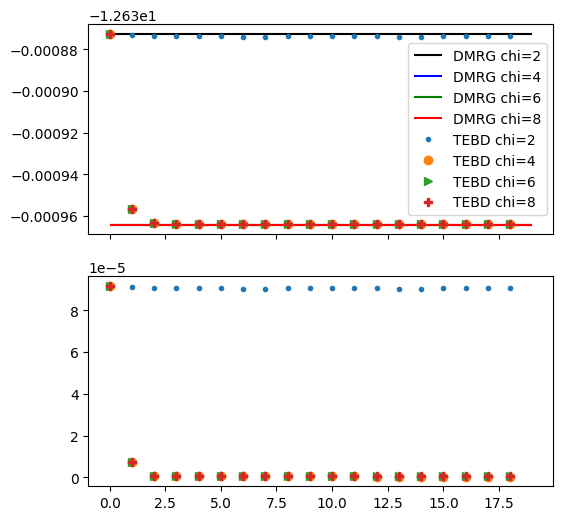

In [44]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(6, 6))
markers = [".", "o", ">", "P"]
colors = ["k", "b", "g", "r"]
for i, chi in enumerate(bond_dims):
    ax[0].hlines(dmrg_energies[i], 0., krylov_energies.shape[1], colors=colors[i], label=f"DMRG chi={chi}")
for i, chi in enumerate(bond_dims):
    ax[0].plot(krylov_energies[i, :], '.', marker=markers[i], label=f"TEBD chi={chi}")
    ax[1].plot(krylov_errs[i, :], '.', marker=markers[i], label=f"TEBD chi={chi}")
ax[0].legend()